# GreenSurge event reconstruction example tropical cyclone

## Read simulation dataset

In [2]:
import xarray as xr
import numpy as np

In [3]:
ds_GFD_info = xr.open_dataset(
    "inputs/GreenSurge_Cadiz_info.nc",
    decode_times=False,
)
ds_GFD_info

<xarray.Dataset> Size: 103kB
Dimensions:                            (element_computation_index: 3732,
                                        triangle_forcing_nodes: 3,
                                        node_forcing_index: 20,
                                        element_forcing_index: 24,
                                        wind_direction_index: 24,
                                        time_forcing_index: 4,
                                        node_cumputation_index: 2087)
Coordinates:
  * element_computation_index          (element_computation_index) int32 15kB ...
  * node_forcing_index                 (node_forcing_index) int32 80B 0 1 ... 19
  * element_forcing_index              (element_forcing_index) int32 96B 0 .....
  * wind_direction_index               (wind_direction_index) int32 96B 0 ... 23
  * time_forcing_index                 (time_forcing_index) float64 32B 0.0 ....
  * node_cumputation_index             (node_cumputation_index) int32 8kB 0 ....
    node_computation_longitude         (node_cumputation_index) float64 17kB ...
    node_computation_latitude          (node_cumputation_index) float64 17kB ...
    triangle_nodes                     (triangle_forcing_nodes) int32 12B ...
Dimensions without coordinates: triangle_forcing_nodes
Data variables: (12/14)
    triangle_computation_connectivity  (element_computation_index, triangle_forcing_nodes) int32 45kB ...
    node_forcing_longitude             (node_forcing_index) float64 160B ...
    node_forcing_latitude              (node_forcing_index) float64 160B ...
    triangle_forcing_connectivity      (element_forcing_index, triangle_forcing_nodes) int32 288B ...
    wind_directions                    (wind_direction_index) int32 96B ...
    total_elements                     int32 4B ...
    ...                                 ...
    wind_speed                         int32 4B ...
    location_name                      object 8B ...
    eddy_viscosity                     int32 4B ...
    chezy_coefficient                  int32 4B ...
    reference_date                     object 8B ...
    forcing_time_step                  int32 4B ...
Attributes:
    title:        GreenSurge Simulation Input Dataset
    institution:  GeoOcean
    model:        GreenSurge
    created:      2026-02-17 13:36:05

In [4]:

p_tracks = "https://geoocean.sci.unican.es/thredds/dodsC/geoceanData/GEOOCEAN/IBTrACS.ALL.v04r00.nc"
xds_tcs = xr.open_dataset(p_tracks)

name_tc, year_tc = "VINCE", 2005


itc = np.where(
    (xds_tcs["name"].values.astype("str") == name_tc)
    & (xds_tcs.isel(date_time=0).time.dt.year.values == year_tc)
)[0]
storm = xds_tcs.isel(storm=itc).squeeze().load()

In [5]:
from bluemath_tk.tcs.tracks import (
    historic_track_interpolation,
    historic_track_preprocessing,
)

centerID = "USA"
df_TC_hist = historic_track_preprocessing(xds=storm, center=centerID);

storm_track, time_input = historic_track_interpolation(df=df_TC_hist, dt_comp=ds_GFD_info.time_step_hours.values * 60)

* Data access can be requested to bluemath@unican.es
You can update any path or add new paths with the update_paths function, from bluemath_tk.config.paths.
Example: update_paths({'SHYTCWAVES_COEFS': '/new/path/to/data'})


## Generate a regular grid for the vortex model and apply the vortex model to the storm track

In [6]:
from bluemath_tk.additive.greensurge import get_regular_grid
from bluemath_tk.tcs.vortex import vortex_model_grid

lon_grid, lat_grid = get_regular_grid(
    node_computation_longitude=ds_GFD_info.node_computation_longitude.values,
    node_computation_latitude=ds_GFD_info.node_computation_latitude.values,
    node_computation_elements=ds_GFD_info.triangle_computation_connectivity.values,
    factor=10,
)

xds_vortex_GS = vortex_model_grid(
    storm_track=storm_track,
    cg_lon=lon_grid,
    cg_lat=lat_grid,
    coords_mode="SPHERICAL",
)

In [7]:
#xds_vortex_GS["W"] = xds_vortex_GS.W * 10

In [8]:
dynamic_path = "outputs/Dynamic/"

In [9]:
from datetime import datetime

reference_datetime = datetime.strptime(
    str(xds_vortex_GS.time.values[0]).split('.')[0].replace('T', ' '),
    "%Y-%m-%d %H:%M:%S"
)
simulation_end_datetime = datetime.strptime(
    str(xds_vortex_GS.time.values[-1]).split('.')[0].replace('T', ' '),
    "%Y-%m-%d %H:%M:%S"
)

drag_coefficients = [0.00063, 0.00723, 0.00723]
velocity_thresholds = [0, 100, 100]
wind_equilibrium_code = 2

metamodel_parameters = {
    "vortex": [xds_vortex_GS],
}

fixed_parameters = {
    "MapInterval": 3600 * ds_GFD_info.time_step_hours.values,
    "RefDate": reference_datetime.strftime("%Y%m%d"),
    "StartDateTime": reference_datetime.strftime("%Y%m%d%H%M%S"),
    "StopDateTime": simulation_end_datetime.strftime("%Y%m%d%H%M%S"),
    "CDa": drag_coefficients[0],
    "CDb": drag_coefficients[1],
    "CDc": drag_coefficients[2],
    "VCDa": velocity_thresholds[0],
    "VCDb": velocity_thresholds[1],
    "VCDc": velocity_thresholds[2],
    "Wind_eq": wind_equilibrium_code,
    "eddy": ds_GFD_info.eddy_viscosity.values,
    "chezy": ds_GFD_info.chezy_coefficient.values,
    "W2Map": 1,
    "dt_forz": ds_GFD_info.forcing_time_step.values,
    "SetupType": "Dynamic",
    "forcing_ds": "forcing.nc",
    "mesh_path": f"templates/mesh_{ds_GFD_info.location_name.values}_net.nc",
    "NetFile": f"mesh_{ds_GFD_info.location_name.values}_net.nc",
}

from bluemath_tk.wrappers.delft3d.delft3d_wrapper import GreenSurgeModelWrapper

delft3d_wrapper = GreenSurgeModelWrapper(
    templates_dir="templates",
    metamodel_parameters=metamodel_parameters,
    fixed_parameters=fixed_parameters,
    output_dir=dynamic_path,
)

delft3d_wrapper.build_cases()

2026-02-17 13:42:01,052 - GreenSurgeModelWrapper - WARNING - Parameter vortex is not in the default_parameters


In [10]:
delft3d_wrapper.run_cases(launcher="launchDelft3dcomp.sh")

ds_WL_dynamic_WindSetUp = xr.open_dataset(f"{dynamic_path}/0000/dflowfmoutput/GreenSurge_GFDcase_map.nc")

In [11]:
from bluemath_tk.additive.greensurge import GS_wind_partition_tri

xds_vortex_interp = GS_wind_partition_tri(
    ds_GFD_info=ds_GFD_info, xds_vortex=xds_vortex_GS
)

In [24]:
figsize = (10, 5)

instant = np.round(np.arange(2/3, 1, 1/12) * len(xds_vortex_interp.time)).astype(int)[:-1]

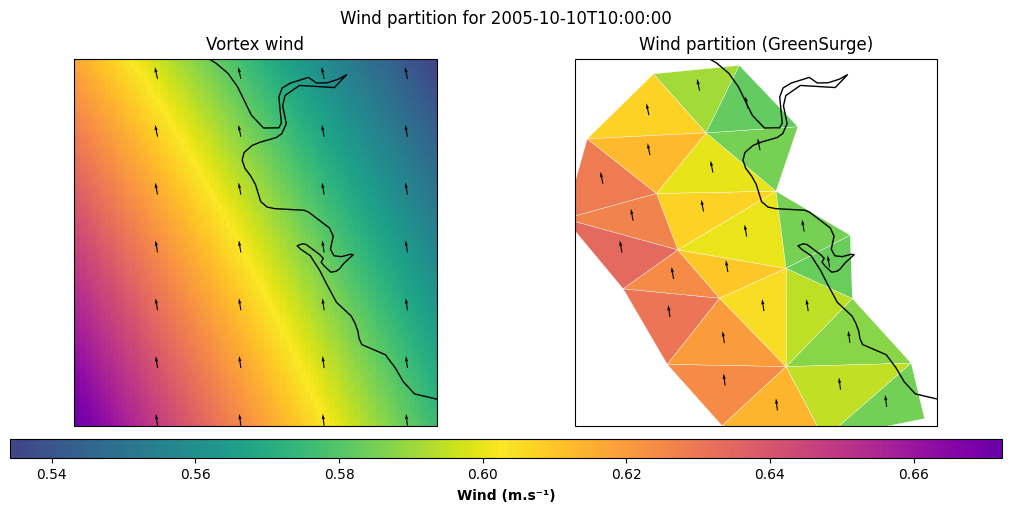

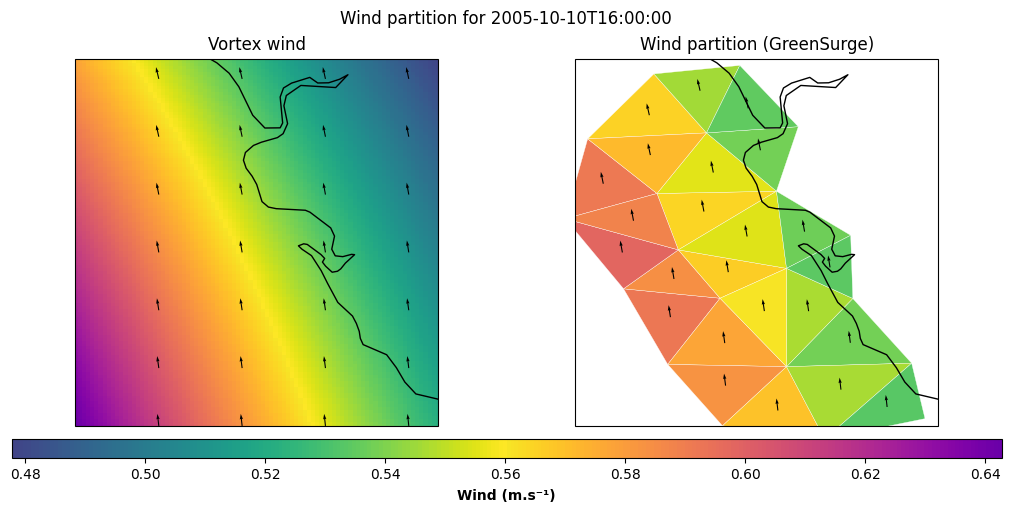

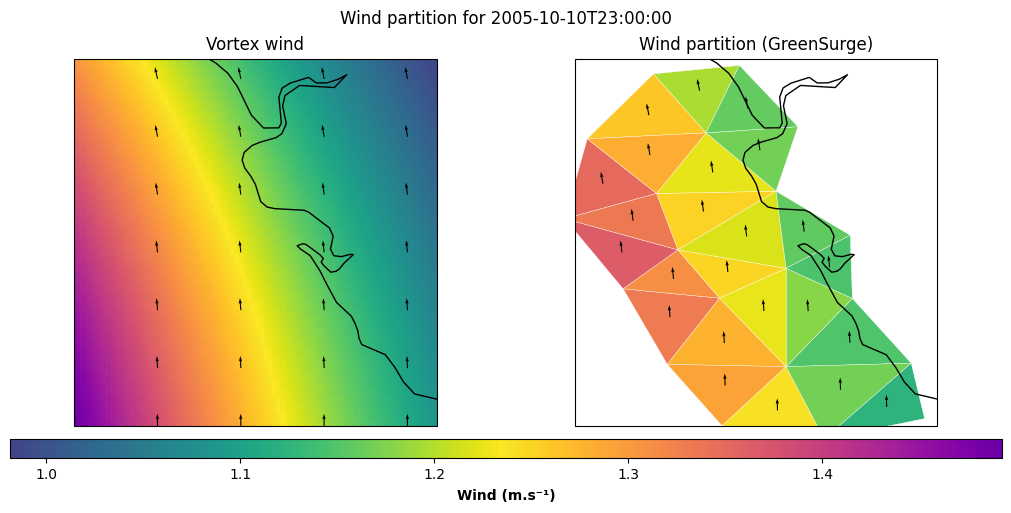

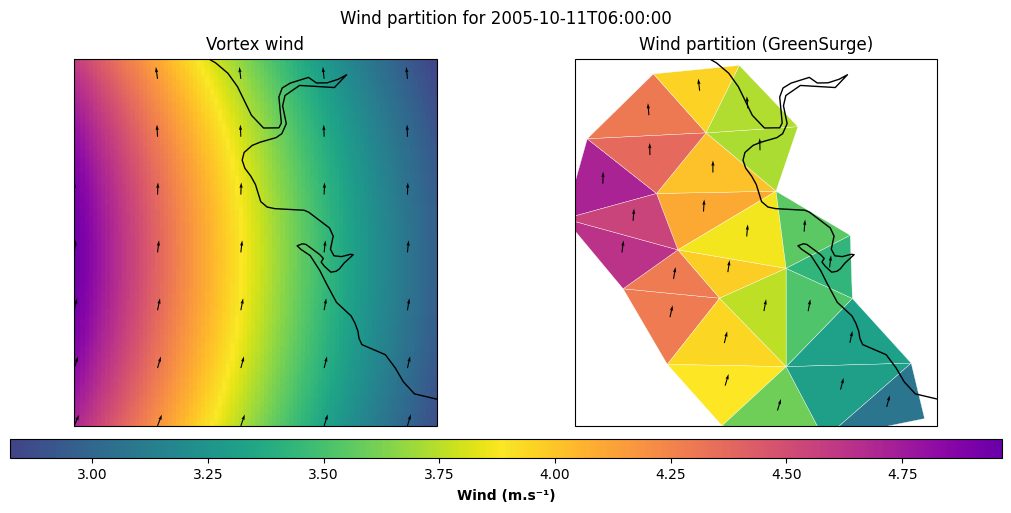

In [25]:
from bluemath_tk.additive.greensurge import plot_GS_input_wind_partition

for i in instant:
    plot_GS_input_wind_partition(
        xds_vortex_GS=xds_vortex_GS,
        xds_vortex_interp=xds_vortex_interp,
        ds_GFD_info=ds_GFD_info,
        i_time=i,
        figsize=figsize,
    )

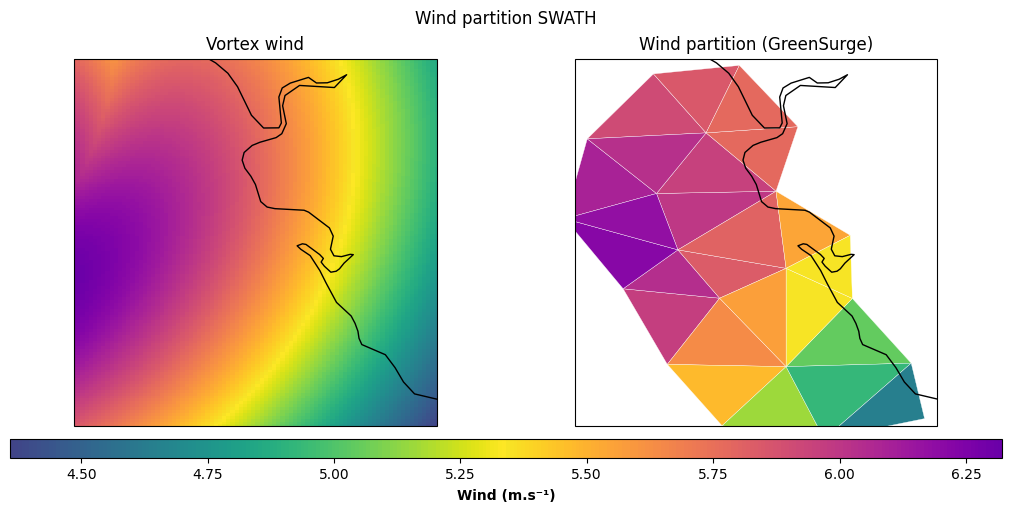

In [26]:
plot_GS_input_wind_partition(
    xds_vortex_GS=xds_vortex_GS,
    xds_vortex_interp=xds_vortex_interp,
    ds_GFD_info=ds_GFD_info,
    SWATH=True,
    figsize=figsize,
)

In [27]:
from bluemath_tk.additive.greensurge import actualize_grid_info

greensurge_dataset="outputs/GreenSurge_Cadiz"

ds_GFD_info_update = actualize_grid_info(f"{greensurge_dataset}/GF_T_0_D_0/dflowfmoutput/GreenSurge_GFDcase_map.nc", ds_GFD_info)

In [28]:
ds_GFD_info_update

<xarray.Dataset> Size: 103kB
Dimensions:                            (element_computation_index: 3732,
                                        triangle_forcing_nodes: 3,
                                        node_forcing_index: 20,
                                        element_forcing_index: 24,
                                        wind_direction_index: 24,
                                        time_forcing_index: 4,
                                        node_cumputation_index: 2087)
Coordinates:
  * element_computation_index          (element_computation_index) int32 15kB ...
  * node_forcing_index                 (node_forcing_index) int32 80B 0 1 ... 19
  * element_forcing_index              (element_forcing_index) int32 96B 0 .....
  * wind_direction_index               (wind_direction_index) int32 96B 0 ... 23
  * time_forcing_index                 (time_forcing_index) float64 32B 0.0 ....
  * node_cumputation_index             (node_cumputation_index) int32 8kB 0 ....
    node_computation_longitude         (node_cumputation_index) float64 17kB ...
    node_computation_latitude          (node_cumputation_index) float64 17kB ...
    triangle_nodes                     (triangle_forcing_nodes) int32 12B ...
Dimensions without coordinates: triangle_forcing_nodes
Data variables: (12/14)
    triangle_computation_connectivity  (element_computation_index, triangle_forcing_nodes) int32 45kB ...
    node_forcing_longitude             (node_forcing_index) float64 160B -6.8...
    node_forcing_latitude              (node_forcing_index) float64 160B 36.6...
    triangle_forcing_connectivity      (element_forcing_index, triangle_forcing_nodes) int32 288B ...
    wind_directions                    (wind_direction_index) int32 96B ...
    total_elements                     int32 4B ...
    ...                                 ...
    wind_speed                         int32 4B ...
    location_name                      object 8B 'Cadiz'
    eddy_viscosity                     int32 4B 10
    chezy_coefficient                  int32 4B 70
    reference_date                     object 8B ...
    forcing_time_step                  int32 4B 1
Attributes:
    title:        GreenSurge Simulation Input Dataset
    institution:  GeoOcean
    model:        GreenSurge
    created:      2026-02-17 13:36:05

In [29]:
from bluemath_tk.additive.greensurge import greensurge_wind_setup_reconstruction_raw

ds_wind_setup = greensurge_wind_setup_reconstruction_raw(greensurge_dataset=greensurge_dataset, 
                                      ds_GFD_info_update=ds_GFD_info_update,
                                      xds_vortex_interp=xds_vortex_interp)

Processing time steps: 100%|██████████| 77/77 [00:00<00:00, 233.11it/s]


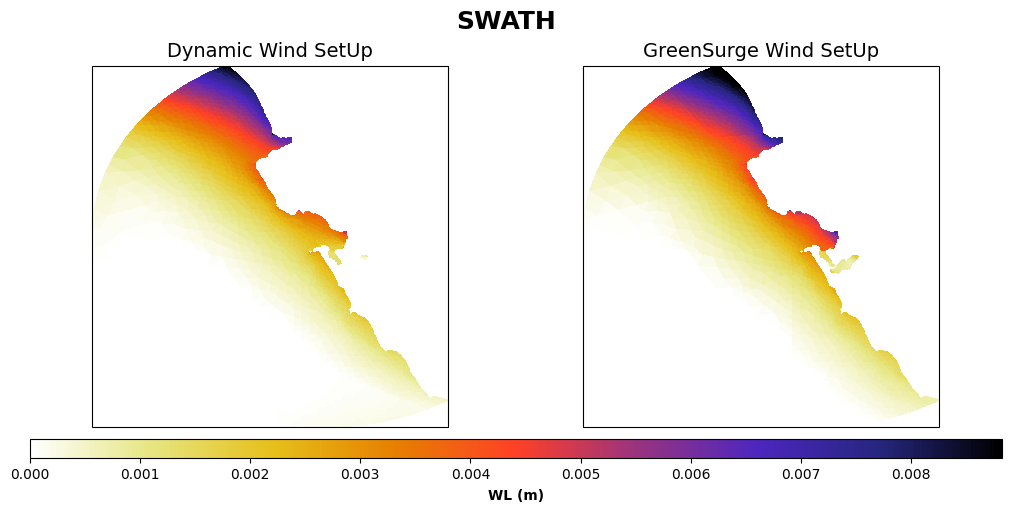

In [30]:
from bluemath_tk.additive.greensurge import plot_GS_vs_dynamic_windsetup_swath

plot_GS_vs_dynamic_windsetup_swath(
    ds_WL_GS_WindSetUp=ds_wind_setup,
    ds_WL_dynamic_WindSetUp=ds_WL_dynamic_WindSetUp,
    ds_gfd_metadata=ds_GFD_info_update,
    vmin=0,
    vmax=np.nanmax(ds_WL_dynamic_WindSetUp.mesh2d_s1.values),
    figsize=figsize,
);

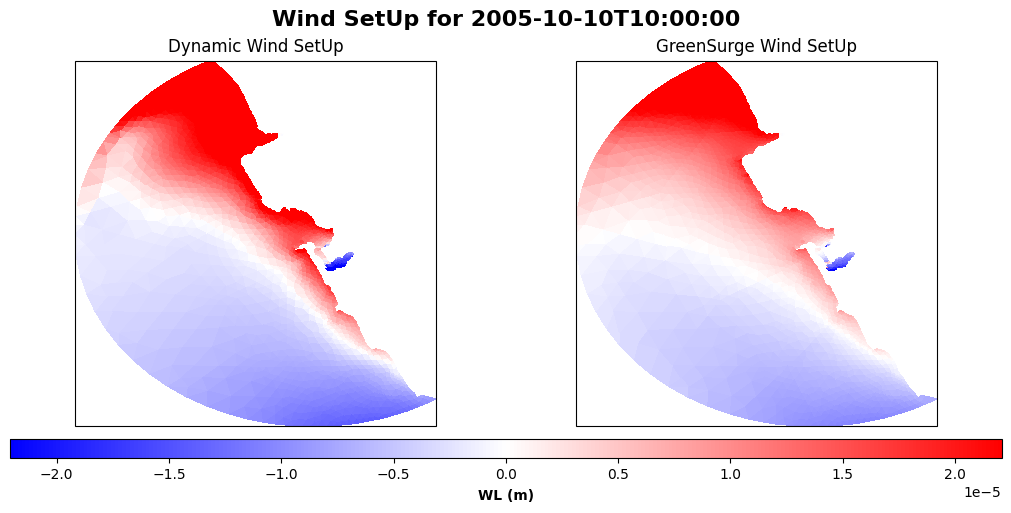

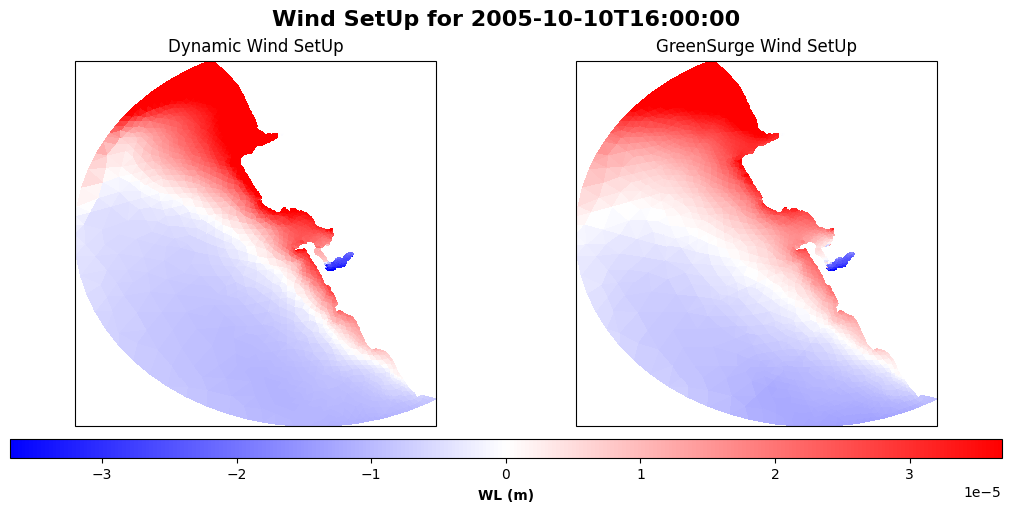

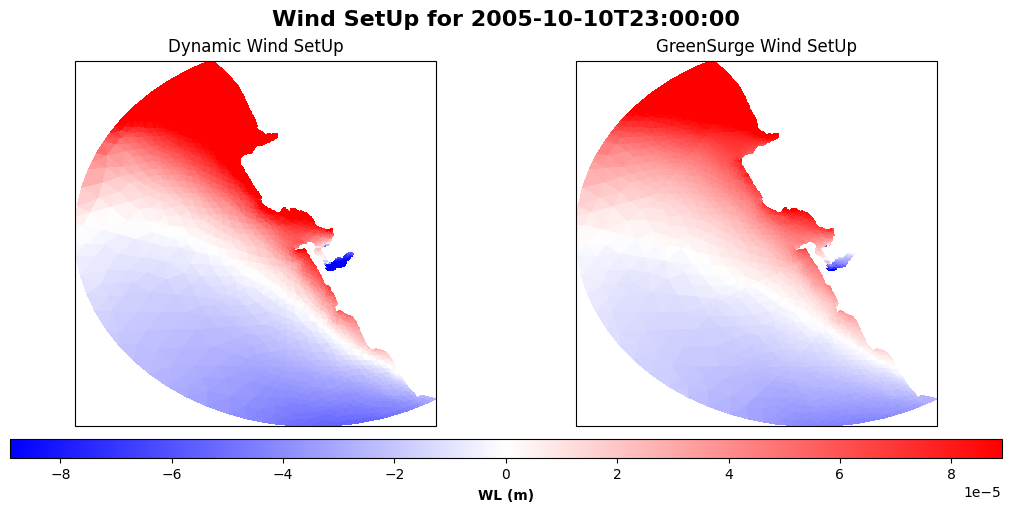

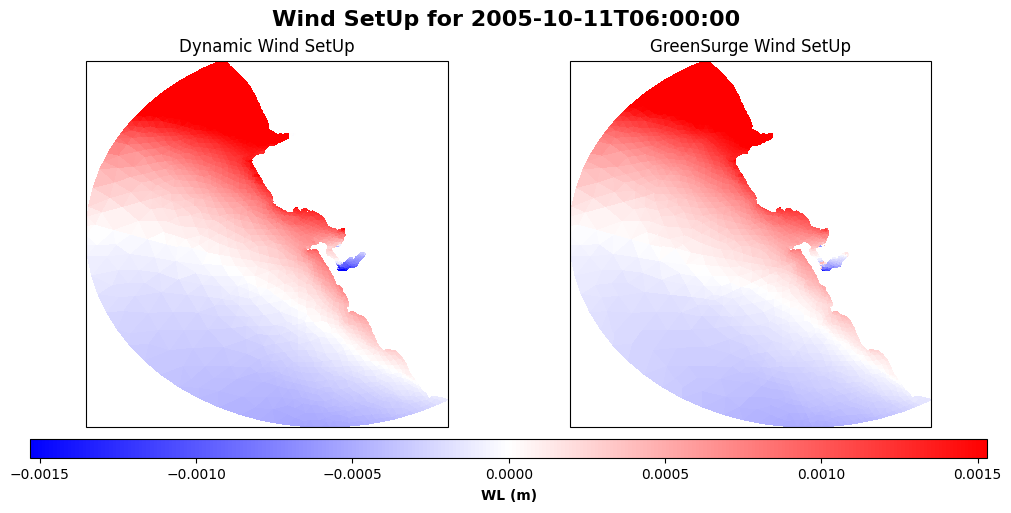

In [31]:
from bluemath_tk.additive.greensurge import plot_GS_vs_dynamic_windsetup

for i in instant:
    plot_GS_vs_dynamic_windsetup(
        ds_WL_GS_WindSetUp = ds_wind_setup,
        ds_WL_dynamic_WindSetUp = ds_WL_dynamic_WindSetUp,
        ds_gfd_metadata = ds_GFD_info_update,
        time = ds_WL_dynamic_WindSetUp.time[i].values,
        figsize = figsize,
    )